# 02 — How the limit is made: from flyby physics to the optimum interval

**Paper element.** Supplemental Material, The Transferred Momentum: figure
`02_spectra` (the differential rate of momentum transfers at the showcase point),
together with the halo, attenuation, cross-section and statistics chain written up
in that section and in Limit Setting.

**What this notebook is.** The pipeline behind
[`01_the_limit.ipynb`](01_the_limit.ipynb), one section per stage. Like
notebook 01 it is **mode-aware**: set `MODE_NUMBER` to pick the sensor mode
whose candidates mark the spectra figure and whose extremeness plane the
appendix spot-checks. That mode's efficiency (shown in
[`00_data_and_selection.ipynb`](00_data_and_selection.ipynb)) enters the
cube's limit surfaces, not the showcase curves drawn here: `/reference_curves`
stores the raw $dR/dq$, before $\varepsilon(q)$, so the two figures below are
the same for every mode.

1. **Halo**: SHM speed distribution at the top of the atmosphere (`luhdm.halo`).
2. **Attenuation**: every trajectory is slowed through the atmosphere by the
   energy-loss ODE (`luhdm.atmosphere`); the detector-frame $f(v)$ carries the
   survival fraction.
3. **Cross section**: classical $K_1$-impulse from a finite-range Yukawa on the
   finite-size magnet (`luhdm.cross_section`; a log-space variant keeps the
   shortest ranges finite where the direct Bessels degrade at large
   $\xi = R_\text{eff}/\lambda$).
4. **Projection kernel**: how that cross section is reduced to the *one
   measured component* of the impulse. This is a convention, not a measurement,
   and the current release changed it; the section below is the whole argument.
5. **Rate**: $dR/dq = \varepsilon(q)\,n_\text{DM}\int f(v)\,v\,(d\sigma/dq)\,dv$,
   assembled by **`luhdm/rate.py`** — the single module imported by the notebooks
   *and* the cluster scripts (`scripts/scan_grid.py`, `scripts/scan_lambda.py`,
   `scripts/make_maps.py`), so the two can never drift. It carries the DM-fraction
   fiducial $f_X$ = `config.F_X` and folds in the per-mode detection efficiency
   $\varepsilon(q)$ shown in notebook 00.
6. **Statistics**: the optimum-interval extremeness (`luhdm.limits`, wrapping the
   public `optimum_interval` package), explained below.

Fiducials (threshold $q_\text{th}$ = 1 TeV/$c$, exposure $T$ = 219.66 h, $f_X$,
$R_\text{eff}$) live in `luhdm/config.py`; the physics that gets tweaked lives in
`luhdm/rate.py`. Change either and the notebooks re-execute unchanged.

Two conventions of the current release run through everything below. The
impact-parameter integral is **uncapped** — the only cutoff is the inner one at
$R_\text{eff}$ — so the excluded region is closed on the right not by the cross
section but by a separate halo flux cut $m_\text{cut}$, stored in the file's
`m_cut_*` attributes and assuming $N_\text{req} = 3$ transits within 10 cm
during the exposure. And the analysis window starts at 1 TeV/$c$, which puts a
hard kinematic wall at $q_\text{th}/v_\text{max} = 3.80\times10^{5}$ GeV on the
left, where $v_\text{max} = v_\text{esc} + v_E$ is the top of the halo's support
in the lab frame this release is built in ($v_E$ = 245 km/s). Neither is visible in the spectra drawn here; both bound the limits of
[`01_the_limit.ipynb`](01_the_limit.ipynb) and are taken apart in
[`03_the_edges.ipynb`](03_the_edges.ipynb).

The showcase curves and diagnostics in this notebook — the arrival-speed
distributions, the spectra, and the appendix spot-check table — are **read from
the data release** (`luhdm_datarelease_v10_A_f1_atm.h5`, the $f_\mathrm{DM}$ = 1
file with atmospheric attenuation — see the version tag in the file /
`release/README.md`), where they were computed
by this same `luhdm.rate` pipeline at build time; the notebook only loads and
plots them, so it can never drift from the cluster scans. The projection-kernel
section is the one place that recomputes anything, and it does so deliberately,
to show what the convention costs.

In [1]:
# ===== CONFIG: which sensor mode this notebook analyses =====
MODE_NUMBER = 1   # 1, 2, or 3

%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, units
from luhdm import release

# File A of the released pair: f_DM = 1 with atmospheric attenuation. It is
# also luhdm.release.DEFAULT_PATH, the --release default of the paper-figure
# scripts, so notebook and script read the same cube.
rel = release.open_release("../release/luhdm_datarelease_v10_A_f1_atm.h5")

# The halo frame is a property of the file, so it is read off the file and
# applied to luhdm.config here, before anything below recomputes a rate: this
# release is built in the LAB frame (v_earth = 245 km/s), where the arrival
# distribution reaches v_esc + v_E rather than v_esc. Recomputing a stored cell
# under the Galactic-rest-frame default would truncate that tail and silently
# disagree with the cube -- the same class of error as using the wrong
# projection kernel, and guarded here the same way.
config.set_v_earth_km_s(rel.v_earth_km_s)
print(f"halo frame     : v_earth = {rel.v_earth_km_s:g} km/s"
      + ("  (Galactic rest frame)" if rel.v_earth_km_s == 0.0
         else "  (lab frame)")
      + f"   v_max = v_esc + v_E = {config.V_MAX * units.C_M_S / 1e3:.0f} km/s")

R_eff = config.R_EFF             # 260 um
Q_THRESH = config.Q_THRESH       # 1 TeV analysis threshold
T_TOTAL = config.T_EXPOSURE      # dataset live-time (single source of truth);
                                  # env-overridable via LUHDM_T_EXPOSURE,
                                  # currently the night-selection exposure (219.66 h)
CONFIDENCE = 0.95
M_PLANCK = 1.22e19               # GeV
# the file carries one hypothesis, f_DM = 1: pass it explicitly, because the
# loader's fallback is the build-side baseline 0.1, which is not on this
# file's axis.
F_DM = 1.0

# seven of the eight named showcase families stored under /reference_curves
# (20 cm is carried there but not loaded here). These arrival-speed and
# spectrum curves are standalone showcase products and all ship in the
# released file; the cube's scanned lambda axis itself carries 2 mm, 200 µm
# and 20 µm, a 200 m convergence-check slice, and the massless sentinel --
# a different set, which is why these tags are listed here by hand rather
# than read off axes/lambda_m. The family is ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
_LAMBS = [2.0, 2e-2, 2e-3, 2e-4, 2e-5, 1e-5, 2e-6]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = {"2um"}                   # loaded and exported, but not drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


import os as _os
for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number
    # prefix, stamped with the data-release version that produced it so
    # a figure always names its cube
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_X = {config.F_X}")

halo frame     : v_earth = 245 km/s  (lab frame)   v_max = v_esc + v_E = 789 km/s
N_n = 1.07e+20   q_th = 1000 GeV   R_eff = 260 um   f_X = 0.1


In [2]:
EVENTS = rel.events(MODE_NUMBER)   # observed impulse candidates [GeV]
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12790.7  6905.1  3509.6  3252.4  2862.   2033.7  1729.4  1520.7]


## Physics model

### Cross-section handles

One handle per mediator range via `luhdm.rate.make_xsec`: the direct
tabulation for $\xi = R_\text{eff}/\lambda \le 30$, the log-space variant
beyond (the direct Bessels degrade and then underflow, $K_1(1000) = 0$ in
float64; agreement is pinned by `tests/test_cross_section_ln.py`), and
`lamb=None` for the **massless analytic limit**
$d\sigma/dq = 2\pi\alpha^2/(v^2q^3)$
(`cross_section.cross_section_rutherford_projection`), used as a reference
line throughout. Strictly, that closed form is the $R_\text{eff}\to0$ limit:
the implemented massless cross section integrates the impact-parameter annulus
$b \ge R_\text{eff}$ and vanishes above the endpoint
$q_\text{max} = 2\alpha/(v\,R_\text{eff})$, so the two agree only below that
endpoint (see `cross_section.cross_section_rutherford_projection_capped` for
the mechanics).


### Differential rate

$dR/dq$ (which the scan then multiplies by the per-mode efficiency
$\varepsilon(q)$; what the release stores, and what is drawn below, is the raw
rate before that factor) and the
companion flux integral (`expected_transits`, used in the Understanding section
and the appendix) come from `luhdm.rate` (in the code, `mu` is the DM mass). The
scan scripts call these exact functions, so the notebook spectra and the cached
limits share one code path.

### Arrival speed distributions

What the atmosphere does to each mediator range, at the showcase point
($m_\text{DM} = 10^8$ GeV, $\alpha_n = 10^{-3}$): the detector-frame speed
distribution $f(v)$ after the energy-loss ODE, with the unattenuated standard
halo model dashed for reference. The area under each curve is the surviving
fraction. Shorter ranges scatter off air nuclei with a smaller transfer cross
section, so they arrive closer to the halo distribution; the longest ranges
are dragged hardest toward low speeds.


     range  survival fraction
       2 m              0.823
      2 cm              0.837
      2 mm              0.797
    200 µm              0.861
     20 µm              0.845
     10 µm              0.851


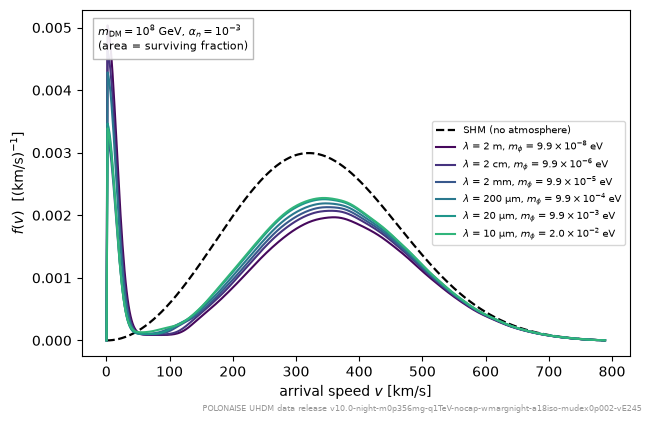

In [3]:
ALPHA_N_SHOW = 1e-3   # showcase coupling the release curves were built at
M_SHOW = 1e8          # showcase DM mass [GeV]

KMS = units.C_M_S / 1e3   # c -> km/s
v, f_shm = rel.speed_dist("shm")   # SHM at the top of the atmosphere

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(v * KMS, f_shm / KMS, "k--", lw=1.6, label="SHM (no atmosphere)")
print(f"{'range':>10} {'survival fraction':>18}")
for tag, lamb, color in LAMBDAS:
    if tag in HIDE:
        continue
    _, fv = rel.speed_dist(tag)
    ax.plot(v * KMS, fv / KMS, color=color, label=range_legend(lamb))
    print(f"{lamb_label(lamb).split(' = ')[-1]:>10} "
          f"{rel.survival_fraction(tag):>18.3f}")
ax.set_xlabel(r"arrival speed $v$ [km/s]")
ax.set_ylabel(r"$f(v)$  [(km/s)$^{-1}$]")
ax.text(0.03, 0.96,
        rf"$m_{{\rm DM}} = 10^8$ GeV, $\alpha_n = 10^{{-3}}$"
        "\n(area = surviving fraction)",
        transform=ax.transAxes, ha="left", va="top", fontsize=8,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(fontsize=7, loc="center right")
fig.tight_layout()
save_figure(fig, "02_arrival_speed_distributions")

### Spectra

The attenuated **raw** $dR/dq$ — before the per-mode efficiency
$\varepsilon(q)$, so the curves are the same for every mode — for the six ranges
drawn here (2 µm is loaded and
exported but hidden; the eighth showcase family, 20 cm, is not loaded by
this notebook) at a fixed mass and coupling. At
fixed coupling the spectrum weakens and steepens as the range shrinks (the
momentum cap $\tilde q < K_1(\xi)$ bites); the longest ranges sit on the
**massless analytic curve** (black dashed,
$d\sigma/dq = 2\pi\alpha^2/(v^2q^3)$), with the endpoint at the halo
kinematic limit.


<>:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_57703/262721452.py:24: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  "\narrival $f(v)$ computed once, at $\lambda$ = 200 µm",


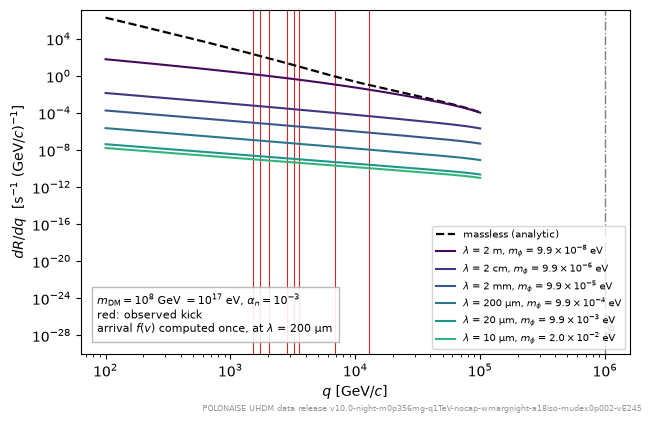

In [4]:
ALPHA_N_SHOW = 1e-3   # showcase coupling
M_SHOW = 1e8          # showcase DM mass [GeV]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
# observed kicks first (thin, behind) so the spectra curves read on top of them
for q_ev in EVENTS:
    ax.axvline(q_ev, color="#d62728", lw=0.8, zorder=0)
q, r_massless = rel.raw_spectrum("massless")
ax.loglog(q, r_massless, color="k", ls="--", lw=1.6, label="massless (analytic)")
for tag, lamb, color in LAMBDAS:
    if tag in HIDE:
        continue
    q, r = rel.raw_spectrum(tag)
    ax.loglog(q, r, color=color, label=range_legend(lamb))
ax.set_ylim(bottom=1e-30)
ax.set_xlabel(r"$q$ [GeV/$c$]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ (GeV/$c$)$^{-1}$]")
ax.axvline(1e6, color="#7f7f7f", lw=1.0, ls="-.")
ax.text(1e6, 0.03, " PeV", color="#555555", fontsize=9, ha="left",
        va="bottom", rotation=90, transform=ax.get_xaxis_transform())
ax.text(0.03, 0.05,
        rf"$m_{{\rm DM}} = 10^8$ GeV $= 10^{{17}}$ eV, $\alpha_n = 10^{{-3}}$"
        "\nred: observed kick"
        "\narrival $f(v)$ computed once, at $\lambda$ = 200 µm",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=8,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(fontsize=7)
fig.tight_layout()
save_figure(fig, "02_spectra")

## The projection kernel: what "$d\sigma/dq$" means here

This is the one step of the chain that is a **convention** rather than a
measurement, and the one the current release changed. A referee asking "why
*this* projection?" is asking about this section.

### What is projected, and onto what

A flyby is an ordinary two-body scattering problem, but the apparatus does not
measure a scattering angle and does not measure the full momentum transfer
vector. A levitated magnet in a differential read-out reports **one Cartesian
component** of the impulse it received, and only its magnitude. So the object
the rest of the analysis needs is neither $d\sigma/d\Omega$ nor
$d\sigma/d|\Delta p|$: it is the differential cross section for the *observed
projection* $q = |\Delta p \cdot \hat n|$ onto the read-out axis $\hat n$.

Written over impact parameter, that is the A18 form

$$\frac{d\sigma}{dq} \;=\; 2\pi \int \frac{b}{|\partial q_\perp/\partial b|}\,db ,$$

the annulus weight $2\pi b\,db$ divided by the Jacobian of the
impulse-versus-impact-parameter map, integrated over the impact parameters that
deliver the observed projection. Everything specific to the convention is in
what $q_\perp(b)$ is taken to be — and that depends on how the incoming
particles are oriented relative to $\hat n$.

### Two kernels, and which one the release ships

`luhdm.cross_section` implements both, selected by a `kernel=` argument:

| | `planar-signed` | `isotropic-folded` (A18) |
|---|---|---|
| arrival geometry | trajectories in the plane containing $\hat n$ | isotropic over the sphere, $\|\cdot\|$ of the one-axis projection |
| Coulomb coefficient | $2\pi\,\alpha^2/(v^2q^3)$ | $\tfrac{8\pi}{3}\,\alpha^2/(v^2q^3)$ |
| shell fraction $F(x)$, $x = b_\text{out}/b_\text{max}$ | $\tfrac{2}{\pi}\big(\arcsin x - x\sqrt{1-x^2}\big)$ | $x^3$ |
| finite $\lambda$ integrand | the arccosh machinery | $\pi\int \beta\,d\beta / K_1(\beta)$ |

Folding the projection over an isotropic arrival distribution replaces the
planar average of the projection by $\langle|\cos\theta|\rangle$ over the
sphere, which is the factor $4/3$ between the two coefficients, and it turns the
shell fraction — the share of the uncapped result contributed by impact
parameters $b \le b_\text{out}$ — from an arcsine into a plain cube. The cube is
not an approximation: under the absolute one-axis projection the disc integral
closes in elementary functions,
$d\sigma/d|q| = \tfrac{\pi v}{3\alpha}\,(b_\text{out}^3 - b_\text{in}^3)$.

`KERNEL_DEFAULT` in `luhdm.cross_section` is still `planar-signed` — the
historical convention, kept so that pre-v9 results reproduce byte for byte. The
v9 cubes were built `isotropic-folded`, and they say so: every released file
carries a root attribute `projection_kernel`, exposed as
`Release.projection_kernel`. **The two are deliberately different**, which is
why recomputing a released cell through the module default is a silent physics
error and `Release.make_xsec` exists.

### Why the floor barely moved and the bulk did

For a massless mediator the only shell that matters is the inner one, the sensor
radius: the $b$-integral runs over $b \ge R_\text{eff}$, so
$x = R_\text{eff}/b_\text{max} = q/q_\text{max}$ with
$q_\text{max} = 2\alpha/(v R_\text{eff})$, and

$$\frac{d\sigma}{dq}\bigg|_\text{iso} = \frac{8\pi}{3}\frac{\alpha^2}{v^2q^3}
\Big(1 - (q/q_\text{max})^3\Big), \qquad
\frac{d\sigma}{dq}\bigg|_\text{planar} = 2\pi\frac{\alpha^2}{v^2q^3}
\Big(1 - F(q/q_\text{max})\Big).$$

Their ratio is a **universal function of $q/q_\text{max}$ alone** — no coupling,
no speed, no mass:

$$R(x) \;=\; \frac{4}{3}\,\frac{1 - x^3}{1 - F(x)} ,
\qquad R(0) = \frac43, \qquad R(0.7456) = 1 .$$

It is monotonically decreasing, and it goes to zero at the endpoint, because the
isotropic kernel vanishes *linearly* in $1 - x$ there while the planar one
vanishes like $\sqrt{1-x}$. So the kernel change is a **gain of 4/3 in the bulk
and a suppression near the endpoint**, with the crossover at
$q/q_\text{max} = 0.7456$. Both statements are drawn below.

That single curve explains what the v9 release did and did not move:

- **Near the deepest point of the coupling floor** the analysis window sits close
  to the spectrum's endpoint — that is what "floor" means here: the smallest
  coupling whose spectrum still reaches 1 TeV at all. The window therefore lives
  where $R(x) < 1$, and the endpoint suppression very nearly cancels the bulk
  gain. Measured across the v8 → v9 change — both of those releases put the halo
  in the Galactic rest frame, so that comparison isolates the kernel — the
  mode-1 massless refined floor moved from $2.570\times10^{-9}$ to
  $2.548\times10^{-9}$: net flat.
- **Everything bulk-dominated strengthened by about the naive $4/3$ in rate.**
  The finite-range islands' high-mass edges, which sit at couplings where the
  whole window is deep in the bulk, moved out by factors of 2.0 to 2.6 in mass,
  and the margin by which the best point clears the exclusion requirement grew
  from $\times3.0$ to $\times7.3$.

Those four v8 → v9 numbers are quoted from the release's own change record, not
recomputed here: the pre-v9 files were dropped from `release/` once every figure
had been re-rendered at v9. Everything else in this section *is* recomputed, from
the released file's own parameters.

cube projection_kernel      : isotropic-folded
module KERNEL_DEFAULT       : planar-signed   <- deliberately the historical one
showcase point              : alpha_n = 0.001, <v> = 1.1280e-03 c, R_eff = 260 um
Coulomb endpoint q_max      : 1.4342e+08 GeV (= 2 alpha / (v R_eff))
ratio at x -> 0             : 1.333333  (= 4/3)
ratio crosses 1 at x = q/q_max = 0.7456
ratio at the showcase window edge q_th/q_max = 6.97e-06: 1.3333


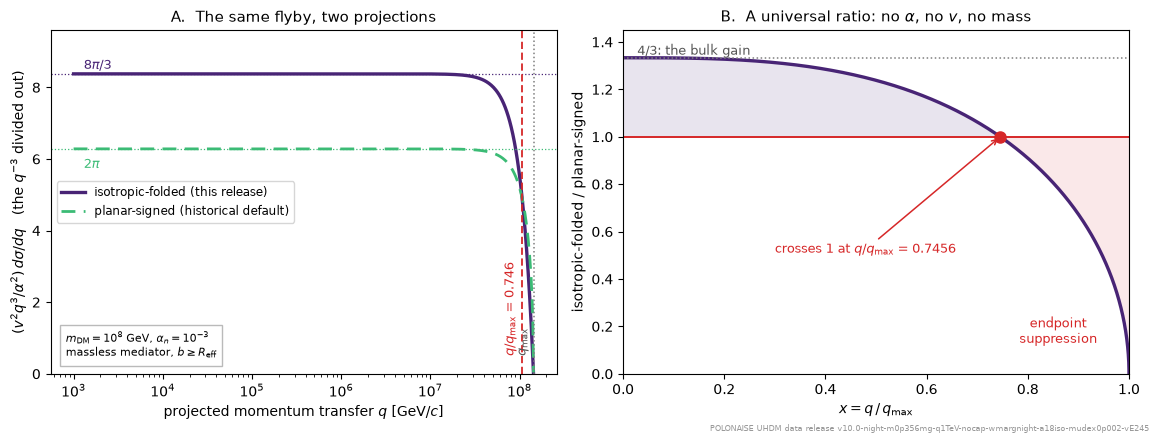

In [5]:
# The two kernels side by side, at the release's own showcase point. Nothing
# here is read from a cube except the parameters and the kernel the cube names:
# both curves are computed live from luhdm.cross_section.
from luhdm import cross_section, halo

# flux-weighted mean halo speed -- the same convention rate.expected_transits
# builds its flux with, so the showcase speed is the release's own
_vv = np.linspace(1e-8, config.V_MAX, 200_000)
V_MEAN = float(np.trapezoid(halo.standard_halo_model(_vv) * _vv, _vv)
               / np.trapezoid(halo.standard_halo_model(_vv), _vv))

ALPHA = ALPHA_N_SHOW * config.N_NEUTRONS          # alpha = alpha_n x N_neutrons
Q_MAX = cross_section.coulomb_q_max(ALPHA, V_MEAN, R_eff)

print(f"cube projection_kernel      : {rel.projection_kernel}")
print(f"module KERNEL_DEFAULT       : {cross_section.KERNEL_DEFAULT}"
      "   <- deliberately the historical one")
print(f"showcase point              : alpha_n = {ALPHA_N_SHOW:g}, "
      f"<v> = {V_MEAN:.4e} c, R_eff = {R_eff * 1e6:.0f} um")
print(f"Coulomb endpoint q_max      : {Q_MAX:.4e} GeV "
      f"(= 2 alpha / (v R_eff))")

QQ = np.geomspace(Q_THRESH, 0.99999 * Q_MAX, 600)
DS_ISO = cross_section.cross_section_rutherford_projection_capped(
    QQ, ALPHA, V_MEAN, None, R_eff=R_eff,
    kernel=cross_section.KERNEL_ISOTROPIC_FOLDED)
DS_PLA = cross_section.cross_section_rutherford_projection_capped(
    QQ, ALPHA, V_MEAN, None, R_eff=R_eff,
    kernel=cross_section.KERNEL_PLANAR_SIGNED)

# the ratio as a universal function of x = q/q_max, computed from the closed
# forms rather than from the two curves, so the crossing can be root-found
def kernel_ratio(x):
    """(iso / planar) dsigma/dq at q = x q_max: 4/3 (1-x^3) / (1 - F(x))."""
    x = np.asarray(x, dtype=float)
    F = (2.0 / np.pi) * (np.arcsin(x) - x * np.sqrt(np.maximum(1 - x * x, 0.0)))
    return (4.0 / 3.0) * (1.0 - x ** 3) / (1.0 - F)


XX = np.linspace(1e-6, 1 - 1e-9, 200_001)
RR = kernel_ratio(XX)
X_CROSS = float(XX[int(np.argmin(np.abs(RR - 1.0)))])
print(f"ratio at x -> 0             : {kernel_ratio(1e-9):.6f}  (= 4/3)")
print(f"ratio crosses 1 at x = q/q_max = {X_CROSS:.4f}")
print(f"ratio at the showcase window edge q_th/q_max = "
      f"{Q_THRESH / Q_MAX:.2e}: {kernel_ratio(Q_THRESH / Q_MAX):.4f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.6, 4.4))

# Both curves fall as q^-3 over eleven decades, which hides everything that
# distinguishes them, so panel A divides that power law out: the ordinate is
# (v^2 q^3 / alpha^2) dsigma/dq, which is exactly 2 pi (1 - F(x)) for the planar
# kernel and (8 pi / 3) (1 - x^3) for the isotropic one. Flat = the bulk.
_COMP = V_MEAN ** 2 * QQ ** 3 / ALPHA ** 2
axA.semilogx(QQ, DS_ISO * _COMP, color=plt.cm.viridis(0.10), lw=2.4,
             label="isotropic-folded (this release)")
axA.semilogx(QQ, DS_PLA * _COMP, color=plt.cm.viridis(0.68), lw=2.0,
             ls=(0, (5, 3)), label="planar-signed (historical default)")
axA.axhline(8 * np.pi / 3, color=plt.cm.viridis(0.10), lw=0.9, ls=":")
axA.text(1.3e3, 8 * np.pi / 3 + 0.12, r"$8\pi/3$", fontsize=9,
         color=plt.cm.viridis(0.10))
axA.axhline(2 * np.pi, color=plt.cm.viridis(0.68), lw=0.9, ls=":")
axA.text(1.3e3, 2 * np.pi - 0.55, r"$2\pi$", fontsize=9,
         color=plt.cm.viridis(0.68))
axA.axvline(Q_MAX, color="#7f7f7f", lw=1.1, ls=":")
axA.text(Q_MAX * 0.88, 0.5, r"$q_{\rm max}$ ", color="#555555", fontsize=9,
         ha="right", va="bottom", rotation=90)
axA.axvline(X_CROSS * Q_MAX, color="#d62728", lw=1.3, ls=(0, (4, 2)))
axA.text(X_CROSS * Q_MAX * 0.88, 0.5,
         f"$q/q_{{\\rm max}}$ = {X_CROSS:.3f} ", color="#d62728", fontsize=9,
         ha="right", va="bottom", rotation=90)
axA.set_ylim(0, 9.6)
axA.set_xlabel(r"projected momentum transfer $q$ [GeV/$c$]")
axA.set_ylabel(r"$(v^2 q^3/\alpha^2)\, d\sigma/dq$   (the $q^{-3}$ divided out)")
axA.set_title("A.  The same flyby, two projections", fontsize=11)
axA.legend(fontsize=8.5, loc="center left")
axA.text(0.03, 0.04, rf"$m_{{\rm DM}} = 10^8$ GeV, $\alpha_n = 10^{{-3}}$"
         "\nmassless mediator, $b \\geq R_{\\rm eff}$",
         transform=axA.transAxes, ha="left", va="bottom", fontsize=8,
         bbox=dict(fc="white", ec="0.7", alpha=0.9))

axB.plot(XX, RR, color=plt.cm.viridis(0.10), lw=2.4)
axB.axhline(4 / 3, color="#7f7f7f", lw=1.1, ls=":")
axB.text(0.02, 4 / 3, " 4/3: the bulk gain", color="#555555", fontsize=9,
         ha="left", va="bottom")
axB.axhline(1.0, color="#d62728", lw=1.4)
axB.plot([X_CROSS], [1.0], "o", ms=8, color="#d62728", zorder=5)
axB.annotate(f"crosses 1 at $q/q_{{\\rm max}}$ = {X_CROSS:.4f}",
             xy=(X_CROSS, 1.0), xytext=(0.30, 0.55), fontsize=9,
             color="#d62728", ha="left", va="top",
             arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.1))
axB.fill_between(XX, 1.0, RR, where=RR >= 1.0, color=plt.cm.viridis(0.10),
                 alpha=0.12, lw=0)
axB.fill_between(XX, RR, 1.0, where=RR < 1.0, color="#d62728", alpha=0.10, lw=0)
axB.text(0.86, 0.18, "endpoint\nsuppression", color="#d62728", fontsize=9,
         ha="center", va="center")
axB.set_xlim(0, 1)
axB.set_ylim(0, 1.45)
axB.set_xlabel(r"$x = q\,/\,q_{\rm max}$")
axB.set_ylabel("isotropic-folded / planar-signed")
axB.set_title("B.  A universal ratio: no $\\alpha$, no $v$, no mass",
              fontsize=11)

fig.tight_layout()
save_figure(fig, "02_projection_kernel")
plt.show()

### Why it has to be the guarded path

The consequence for anyone recomputing a released cell is not subtle. Below,
one cell of the bare-halo (file B) $\mu$ surface is recomputed twice from the
same `luhdm.rate` code, differing only in which kernel the cross-section handle
was built with: `rel.make_xsec(None)`, which threads the *file's* convention,
against `rate.make_xsec(None)`, which takes the module default. The cell is
picked near $\mu = 3$ on purpose — it is the kind of cell that decides whether a
point is inside the excluded region or outside it.

`Release.make_xsec` is the supported way to do this. It fills in the file's
`projection_kernel` *and* its `b_constrained_max` (both `None`/uncapped here),
so a recomputed $d\sigma/dq$, $dR/dq$ or $\mu$ is comparable with the stored
surface; naming either keyword explicitly still overrides the file, which is
then a deliberate act rather than an accident. `release/README.md` §5.5
documents the attribute; notebook
[`03_the_edges.ipynb`](03_the_edges.ipynb) uses the same handle for its
replication checks.

In [6]:
# One released cell, recomputed both ways. File B carries the bare-halo pass,
# which is what this cell can reproduce without re-running the attenuation ODE.
from luhdm import efficiency, limits, rate

relB = release.open_release("../release/luhdm_datarelease_v10_B_f0p1_noatm.h5")
assert relB.projection_kernel == rel.projection_kernel, \
    "the two released files name different projection kernels"

_eps = efficiency.make_efficiency(MODE_NUMBER, df=3)
QS_BUILD = np.geomspace(Q_THRESH, 3e4 * 8.4e3, 240)   # the release build's grid


def mu_recomputed(m_gev, alpha_n, xs, f_dm=0.1):
    """The release build's own arithmetic for one cell, bare halo."""
    dr = rate.differential_rate_trapz(QS_BUILD, alpha_n, m_gev,
                                      halo.standard_halo_model, xs,
                                      eff=None) * _eps(QS_BUILD)
    spec = limits.spectrum_from_rate(QS_BUILD, dr, T_TOTAL)
    return 0.0 if spec is None else (f_dm / config.F_X) * spec[0]


MU_B = relB.mass_plane("mu", mode=MODE_NUMBER, lam="massless", f_dm=0.1,
                       atmosphere=False)
# a cell at the exclusion requirement rather than an arbitrary one: at
# m_DM ~ 1e8 GeV, the stored coupling row whose expected count sits closest to
# the -ln(0.05) = 3.0 the limit is bought at. It is read off the cube, so a
# rebuild on a different coupling axis still lands on the boundary.
_im = relB.at_mass(1e8)
_col = MU_B[:, _im]
_ia = int(np.nanargmin(np.abs(np.log(np.where(_col > 0, _col, np.nan))
                              - np.log(-np.log(0.05)))))
M_CELL = float(relB.axes.mass_gev[_im])
A_CELL = float(relB.axes.alpha_n[_ia])
STORED = float(MU_B[_ia, _im])

RIGHT = mu_recomputed(M_CELL, A_CELL, relB.make_xsec(None))
WRONG = mu_recomputed(M_CELL, A_CELL, rate.make_xsec(None))

print(f"cell: m_DM = {M_CELL:.4e} GeV, alpha_n = {A_CELL:.4e}, "
      f"massless, bare halo, f_DM = 0.1")
print(f"  stored in the cube                     mu = {STORED:.6f}")
print(f"  relB.make_xsec  ({relB.projection_kernel:16s}) mu = {RIGHT:.6f}"
      f"   rel. diff {abs(RIGHT / STORED - 1):.2e}")
print(f"  rate.make_xsec  ({cross_section.KERNEL_DEFAULT:16s}) mu = {WRONG:.6f}"
      f"   rel. diff {abs(WRONG / STORED - 1):.2e}")
print(f"  the wrong handle is off by {abs(WRONG / STORED - 1) * 100:.1f}% -- "
      f"and this cell sits at mu ~ {STORED:.1f}, i.e. right at the "
      f"-ln(0.05) = 3.0 requirement")

# the guarded path reproduces the file; the unguarded one does not
assert abs(RIGHT / STORED - 1) < 1e-6, \
    "rel.make_xsec does not reproduce the cube's own mu cell"
assert abs(WRONG / STORED - 1) > 0.05, \
    "the module default no longer differs from the cube -- has KERNEL_DEFAULT moved?"
relB.close()

cell: m_DM = 9.6471e+07 GeV, alpha_n = 1.2389e-08, massless, bare halo, f_DM = 0.1
  stored in the cube                     mu = 7.355874
  relB.make_xsec  (isotropic-folded) mu = 7.355874   rel. diff 1.26e-08
  rate.make_xsec  (planar-signed   ) mu = 6.400567   rel. diff 1.30e-01
  the wrong handle is off by 13.0% -- and this cell sits at mu ~ 7.4, i.e. right at the -ln(0.05) = 3.0 requirement


## Statistics: what the extremeness means

At each grid point the extremeness is

$$p = \Pr\big(C_\text{max}^\text{pseudo} < C_\text{max}^\text{obs}\,\big|\,m_\text{DM}, \alpha_n,\ \text{no background}\big),$$

the fraction of background-free pseudo-experiments generated *under that
hypothesis* whose most-anomalously-empty spectral stretch looks **less** empty
than the data. Physically: $p = 0.95$ means the hypothesis predicts enough
events that 95% of the time our gaps would have been filled in more than they
are: the observed emptiness sits in the 5% tail, so the point is excluded at
95% CL. The surface *is* the confidence level: the rule "exclude where
$p \ge C$" wrongly rejects a true hypothesis at most $(1-C)$ of the time
(frequentist coverage, not a posterior probability), and any CL is a level set
of the same array; the 90% contour needs no rescan. The test is one-sided by
construction: background can only *add* events, filling gaps and lowering $p$,
so backgrounds can weaken an exclusion but never fake one. This full extremeness
surface ships assembled in the data release, so every confidence level here is
just a level set read straight from it.

## Scan mechanics

Each scan is a parallel sweep over grid points; at each point: attenuation
ODE → $dR/dq$ → expected count
$\mu$ and normalized spectrum shape → optimum-interval extremeness of the
observed events. Because the spectrum shape depends on the coupling being
limited (finite range, attenuation), the limit is a **level set of the
extremeness surface**, not a single $\mu$ solve. Monte-Carlo calibration
tables are shared across the plane by rounding $\mu$ onto a 2%-spaced log
grid. Runtime knobs: `n_grid`/`n_ode` (attenuation ODE resolution, the
dominant cost), `n_mc` (calibration statistics), and the grid densities; see
`FID` in the scripts. These scans ship pre-assembled in the data release
(the current release cube — see the version tag in the file /
`release/README.md`), so the notebooks read the finished cube
rather than recomputing it.

## Appendix: validation checks

1. **$K_1$ → Coulomb convergence.** At $\lambda$ = 2 m and small coupling
   (threshold kicks come from close flybys, $b \ll \lambda$, the Coulomb
   regime), the tabulated $K_1$ machinery must reproduce the closed form
   $c\,\alpha^2/(v^2 q^3)$, whose coefficient is set by the cube's projection
   kernel — $8\pi/3$ for the isotropic-folded convention this release ships,
   $2\pi$ for the historical planar-signed one. Both sides of the check are
   built under whichever kernel the open file names, so the ratios below should
   be $\approx 1$ either way.
2. **Log-space vs direct.** Of the ranges loaded here only $\lambda$ = 2 µm
   reaches the log-space branch ($\xi = R_\text{eff}/\lambda = 130$, past the
   $\xi > 30$ switch); 10 µm is already direct at $\xi = 26$, and the released
   $\lambda$ axis — 20 µm, 200 µm, 2 mm, the 200 m convergence slice and the
   massless sentinel — tops out at $\xi = 13$, so the scanned cube is entirely
   direct. `tests/test_cross_section_ln.py` pins agreement between the two
   paths at the percent level wherever both are healthy
   ($\xi \le 10$ across the tabulated range), and finiteness at $\xi = 1000$
   where the direct $K_1$ underflows. Run `pytest` to reproduce.
3. **Spot checks along the reference contour.** The reach $b_\text{max}$, the
   transit count $N_t$, and $\mu$ at ten points on the 95% boundary, read
   cell-by-cell from the release. Here $b_\text{max}$ is the
   **flux-averaged reach** $\sqrt{\langle b^2\rangle}$ read from the halo cube,
   systematically smaller than a max-over-$v$ impact parameter would be; the
   physical claim is the same either way, since the reach stays far below the
   apparatus scale,
   so the point-sensor impulse model is safe on the boundary. Expect
   $N_t \ge \mu \gtrsim 3$ everywhere (exclusion is never claimed where no
   particle is expected to pass within reach).

The spot checks below read the 200 µm extremeness plane straight from the data
release and trace its 95% contour:

In [7]:
# validate: K1 machinery at lambda = 2 m vs the analytic Coulomb projection.
# Coulomb regime requires b << lambda, i.e. q_tilde >> 1: pick a small coupling
# so threshold kicks come from close flybys.
import os
os.environ["TQDM_DISABLE"] = "1"
from luhdm import cross_section, rate

# Both sides are built under the CUBE's projection kernel, read off the file:
# the two kernels differ by a fixed factor in the Coulomb limit, so comparing a
# handle built one way against a closed form written the other way would pass
# or fail for the wrong reason. rel.make_xsec threads the file's convention.
XS_2M = rel.make_xsec(2.0)   # 2 m mediator handle, built here for this check
alpha_chk = 1e-6 * config.N_NEUTRONS
v_chk = 1e-3
qs_chk = np.geomspace(Q_THRESH, 10 * Q_THRESH, 6)
num = rate.dsigma_dq_any(qs_chk, alpha_chk, v_chk, XS_2M)
ana = cross_section.cross_section_rutherford_projection_capped(
    qs_chk, alpha_chk, v_chk, None, kernel=rel.projection_kernel)
print(f"projection kernel: {rel.projection_kernel}")
print("K1 machinery / analytic (should be ~1):", np.round(num / ana, 4))

  0%|          | 0/899 [00:00<?, ?it/s]

  3%|▎         | 29/899 [00:00<00:03, 286.70it/s]

  7%|▋         | 60/899 [00:00<00:02, 297.10it/s]

 10%|█         | 90/899 [00:00<00:02, 279.05it/s]

 13%|█▎        | 119/899 [00:00<00:03, 248.34it/s]

...

 82%|████████▏ | 736/899 [00:02<00:00, 471.18it/s]

 88%|████████▊ | 794/899 [00:02<00:00, 500.68it/s]

 95%|█████████▍| 852/899 [00:02<00:00, 523.73it/s]

100%|██████████| 899/899 [00:02<00:00, 324.98it/s]

projection kernel: isotropic-folded
K1 machinery / analytic (should be ~1): [1.0083 1.0149 1.0186 1.0178 1.0136 1.0054]


In [8]:
# 95% contour of the reference-range (200 µm) extremeness plane, read straight
# from the release; sample ~10 boundary points and dump each cell.
REF_TAG = "200um"
ext_ref = rel.mass_plane("extremeness", mode=MODE_NUMBER, lam=REF_TAG,
                         f_dm=F_DM)
ms_ref = rel.axes.mass_gev
alphas_ref = rel.axes.alpha_n

_f, _a = plt.subplots()
cs95_ref = _a.contour(ms_ref, alphas_ref, ext_ref, levels=[CONFIDENCE])
plt.close(_f)

def contour_polyline(cs):
    parts = []
    for seg in cs.allsegs[0]:
        parts.append(seg)
        parts.append(np.full((1, 2), np.nan))
    return np.vstack(parts) if parts else np.empty((0, 2))

poly = contour_polyline(cs95_ref)
pts = poly[~np.isnan(poly).any(axis=1)]

# b_max is now the flux-averaged reach sqrt(<b^2>) taken from the halo cube
# (systematically smaller than the old max-over-v impact parameter); the
# physical claim -- reach far below the apparatus scale -- is unchanged.
print(f"{'m [GeV]':>10} {'alpha_n':>9} {'b_max flux-avg [cm]':>20} "
      f"{'N_transit':>10} {'mu':>7}")
if len(pts) == 0:
    print("(no 95% contour on this plane)")
else:
    idx = np.linspace(0, len(pts) - 1, 10).astype(int)
    for m, a in pts[idx]:
        c = rel.cell(m, a, REF_TAG, mode=MODE_NUMBER, f_dm=F_DM)
        print(f"{c['mass_gev']:>10.2e} {c['alpha_n']:>9.1e} "
              f"{c['bmax'] * 100:>20.2e} {c['n_transit']:>10.1f} {c['mu']:>7.2f}")
    print("\nN_transit >= mu everywhere: exclusion is never claimed where fewer "
          "than ~3 particles are expected within reach.")

   m [GeV]   alpha_n  b_max flux-avg [cm]  N_transit      mu
  3.56e+06   7.3e-09             6.97e-03      384.3    3.53
  1.67e+08   2.1e-08             3.39e-02      159.4   10.44
  5.96e+09   5.3e-07             8.52e-02       30.9   16.08
  5.37e+10   6.5e-05             1.71e-01       14.2   10.54
  2.12e+11   4.0e-02             2.98e-01        8.6    7.02
  5.96e+09   4.0e-02             2.98e-01       16.1   10.96
  9.65e+07   4.7e-03             2.53e-01      878.5  385.23
  2.06e+06   9.5e-04             2.23e-01     2087.5  249.37
  5.20e+05   1.5e-06             9.47e-02    31466.6  228.17
  3.56e+06   7.3e-09             6.97e-03      384.3    3.53

N_transit >= mu everywhere: exclusion is never claimed where fewer than ~3 particles are expected within reach.
